In [42]:
# =========================================
# INSTALL & IMPORT LIBRARIES
# =========================================
!pip install xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer, KNNImputer
from scipy.stats.mstats import winsorize

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import shap

In [43]:
uploaded=files.upload()

Saving heart_disease.csv to heart_disease (2).csv


In [44]:
df=pd.read_csv('heart_disease.csv')

In [14]:
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [62]:
print("Dataset shape:", df.shape)
print("Data Duplicates:", df.duplicated().sum())
print("\n")
print(df["target_binary"].value_counts())
print("\n")
print("Counting Missing values:\n", df.isnull().sum())


Dataset shape: (1024, 16)
Data Duplicates: 0


target_binary
0    554
1    470
Name: count, dtype: int64


Counting Missing values:
 age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
num              0
target_binary    0
anomaly          0
dtype: int64


In [56]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary,anomaly
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984,0.898438
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558,0.439316
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,-1.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000,1.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000,1.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000,1.000000


In [48]:
#Function to detect outliers in dataset

#Using IQR
#def detect_outliers_iqr(df):
 #   outliers = {}

  #  for col in df.select_dtypes(include=np.number).columns:
   #     Q1 = df[col].quantile(0.25)
    #    Q3 = df[col].quantile(0.75)
     #   IQR = Q3 - Q1

      #  lower = Q1 - 1.5 * IQR
       # upper = Q3 + 1.5 * IQR

        #outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()

    #return outliers

#print(detect_outliers_iqr(df))


#Using Zscore
#from scipy.stats import zscore

#z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))
#outliers = (z_scores > 3).sum(axis=0)

#print(outliers)

#Using heatmap
#corr = df.corr()

#plt.figure(figsize=(10,8))
#sns.heatmap(corr, annot=True, cmap='coolwarm')
#plt.show()

#Using Isolation forest
#from sklearn.ensemble import IsolationForest

#iso = IsolationForest(contamination=0.05, random_state=42)
#preds = iso.fit_predict(df.select_dtypes(include=np.number))

#df['anomaly'] = preds

#print(df['anomaly'].value_counts())


In [69]:
x=df.drop(['target_binary'], axis=1)
y=df['target_binary']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)


In [71]:
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [72]:
# EVALUATION FUNCTION
# =========================================
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }


In [73]:
# CROSS-VALIDATION FUNCTION
# =========================================
def evaluate_with_cv(model, X, y, seeds=[42,52,62], cv=5):
    results = []

    for seed in seeds:
        kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
        scores = cross_val_score(model, X, y, cv=kfold, scoring='f1')
        results.append(scores.mean())

    return np.mean(results), np.std(results)


In [74]:
# RESULTS STORAGE
# =========================================
results = []
cv_results = []

In [76]:
# BASELINE
# =========================================
for name, model in {"RF": rf_model, "XGB": xgb_model}.items():
    res = evaluate_model(model, X_train, X_test, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(model, X_train, y_train)

    results.append(["Baseline", name, res["F1"]])
    cv_results.append(["Baseline", name, mean_cv, std_cv])

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:26:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [77]:
# OUTLIER REMOVAL (IQR)
# =========================================
def remove_outliers_iqr(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    return X[mask], y[mask]

X_train_iqr, y_train_iqr = remove_outliers_iqr(X_train, y_train)

for name, model in {"RF": rf_model, "XGB": xgb_model}.items():
    res = evaluate_model(model, X_train_iqr, X_test, y_train_iqr, y_test)
    mean_cv, std_cv = evaluate_with_cv(model, X_train_iqr, y_train_iqr)

    results.append(["IQR", name, res["F1"]])
    cv_results.append(["IQR", name, mean_cv, std_cv])


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:40:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:40:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:40:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:40:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [78]:
# WINSORIZATION
# =========================================
def winsorize_data(X):
    X_wins = X.copy()
    for col in X.columns:
        X_wins[col] = winsorize(X[col], limits=[0.05, 0.05])
    return pd.DataFrame(X_wins, columns=X.columns)

X_train_win = winsorize_data(X_train)
X_test_win = winsorize_data(X_test)

for name, model in {"RF": rf_model, "XGB": xgb_model}.items():
    res = evaluate_model(model, X_train_win, X_test_win, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(model, X_train_win, y_train)

    results.append(["Winsor", name, res["F1"]])
    cv_results.append(["Winsor", name, mean_cv, std_cv])

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:41:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:41:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:41:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:41:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [79]:
# INTRODUCING MISSING DATA
# =========================================
def introduce_missing(X, rate=0.1):
    X_missing = X.copy()
    mask = np.random.rand(*X.shape) < rate
    X_missing[mask] = np.nan
    return X_missing

X_train_miss = introduce_missing(X_train, 0.1)
X_test_miss = introduce_missing(X_test, 0.1)


# ---- Mean Imputation ----
mean_imputer = SimpleImputer(strategy="mean")
X_train_mean = mean_imputer.fit_transform(X_train_miss)
X_test_mean = mean_imputer.transform(X_test_miss)

for name, model in {"RF": rf_model, "XGB": xgb_model}.items():
    res = evaluate_model(model, X_train_mean, X_test_mean, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(model, X_train_mean, y_train)

    results.append(["Mean", name, res["F1"]])
    cv_results.append(["Mean", name, mean_cv, std_cv])


# ---- KNN Imputation ----
knn_imputer = KNNImputer(n_neighbors=5)
X_train_knn = knn_imputer.fit_transform(X_train_miss)
X_test_knn = knn_imputer.transform(X_test_miss)

for name, model in {"RF": rf_model, "XGB": xgb_model}.items():
    res = evaluate_model(model, X_train_knn, X_test_knn, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(model, X_train_knn, y_train)

    results.append(["KNN", name, res["F1"]])
    cv_results.append(["KNN", name, mean_cv, std_cv])


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:42:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:42:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:42:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:42:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [81]:
 # RESULTS TABLES
# =========================================
results_df = pd.DataFrame(results, columns=["Experiment", "Model", "F1"])
cv_results_df = pd.DataFrame(cv_results, columns=["Experiment", "Model", "Mean_F1", "Std"])

print("\nTest Results:")
display(results_df)

print("\nCross-Validation Results:")
display(cv_results_df)



Test Results:


,Experiment,Model,F1
0,Baseline,RF,1.000000
1,Baseline,XGB,1.000000
2,IQR,RF,1.000000
3,IQR,XGB,1.000000
4,Winsor,RF,1.000000
5,Winsor,XGB,1.000000
6,Mean,RF,0.978261
7,Mean,XGB,0.978261
8,KNN,RF,0.957447
9,KNN,XGB,0.968085



Cross-Validation Results:


,Experiment,Model,Mean_F1,Std
0,Baseline,RF,1.000000,0.000000
1,Baseline,XGB,1.000000,0.000000
2,IQR,RF,1.000000,0.000000
3,IQR,XGB,1.000000,0.000000
4,Winsor,RF,1.000000,0.000000
5,Winsor,XGB,1.000000,0.000000
6,Mean,RF,0.982637,0.001913
7,Mean,XGB,0.974720,0.001104
8,KNN,RF,0.966024,0.002701
9,KNN,XGB,0.963332,0.000628


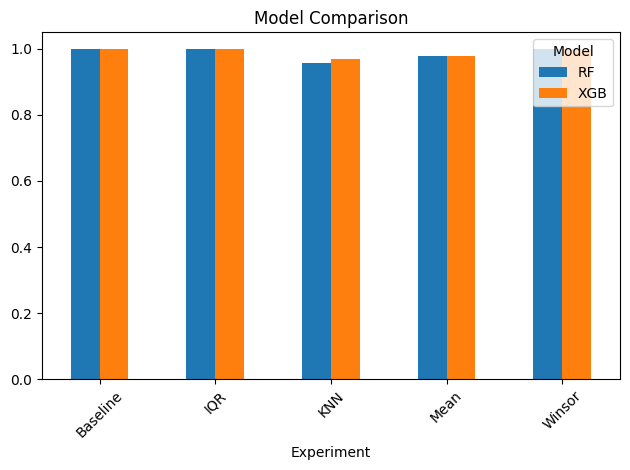

In [82]:
# PLOT
# =========================================
results_df.pivot(index="Experiment", columns="Model", values="F1").plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


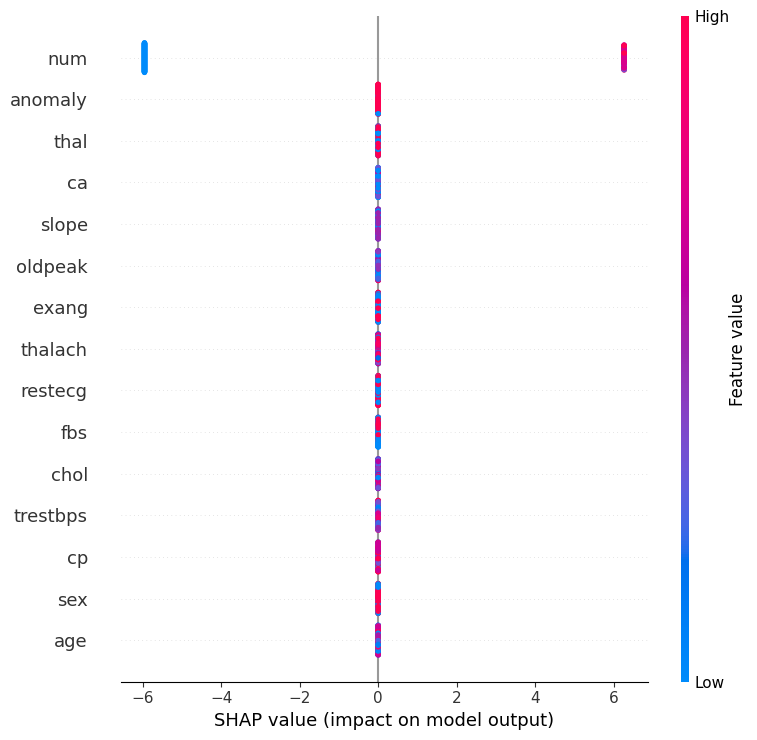

In [83]:
# EXPLAINABILITY (SHAP)
# =========================================
xgb_model.fit(X_train, y_train)

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)